# Setup Environment

In [9]:
# Import libraries

# Standard libraries
from pathlib import Path

# Data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Models
import sklearn 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Model evaluators
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import RocCurveDisplay

# Saving and loading models
import joblib

print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

NumPy version: 2.4.1
pandas version: 3.0.3
matplotlib version: 3.11.0
seaborn version: 0.13.2
Scikit-Learn version: 1.9.0


In [10]:
# Create image and model directories if they don't exist
plots_dir = Path("plots")
models_dir = Path("models")

if not plots_dir.exists():
    plots_dir.mkdir()

if not models_dir.exists():
    models_dir.mkdir()

print("Directories created (if they didn't exist): plots, models")

Directories created (if they didn't exist): plots, models


# Data Loading and Exploratory Data Analysis (EDA)

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


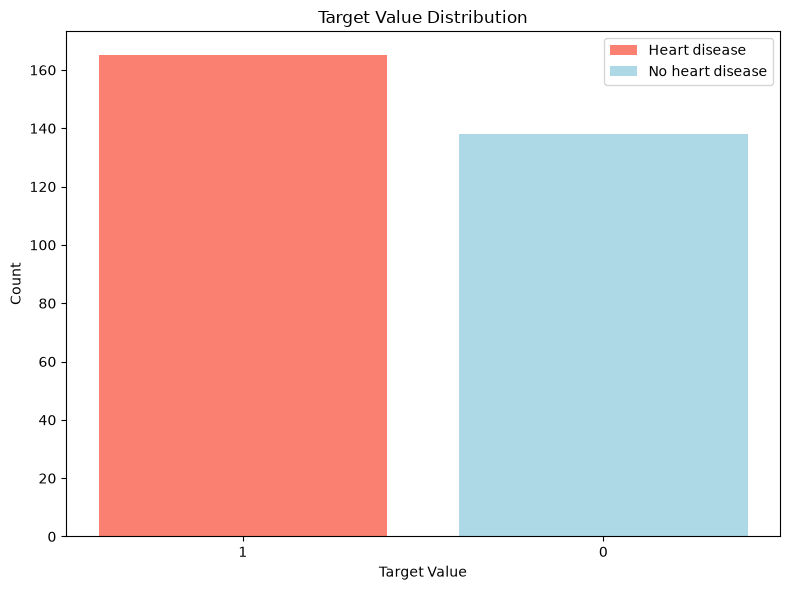

In [11]:
# Exploratory data analysis (EDA)

# Load the data
df = pd.read_csv('heart-disease.csv')

# Check for missing values, data types, and summary statistics
df.isnull().sum()
df.info()
df.describe()

# Plot the distribution of the target variable
counts = df.target.value_counts()

plt.figure(figsize=(8, 6))
plt.bar(0, counts[1], color="salmon", label="Heart disease")
plt.bar(1, counts[0], color="lightblue", label="No heart disease")


plt.title("Target Value Distribution")
plt.xlabel("Target Value")
plt.ylabel("Count")
plt.xticks([0, 1], ["1", "0"])
plt.legend()
plt.tight_layout()
plt.savefig("plots/01_EDA_target_value_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

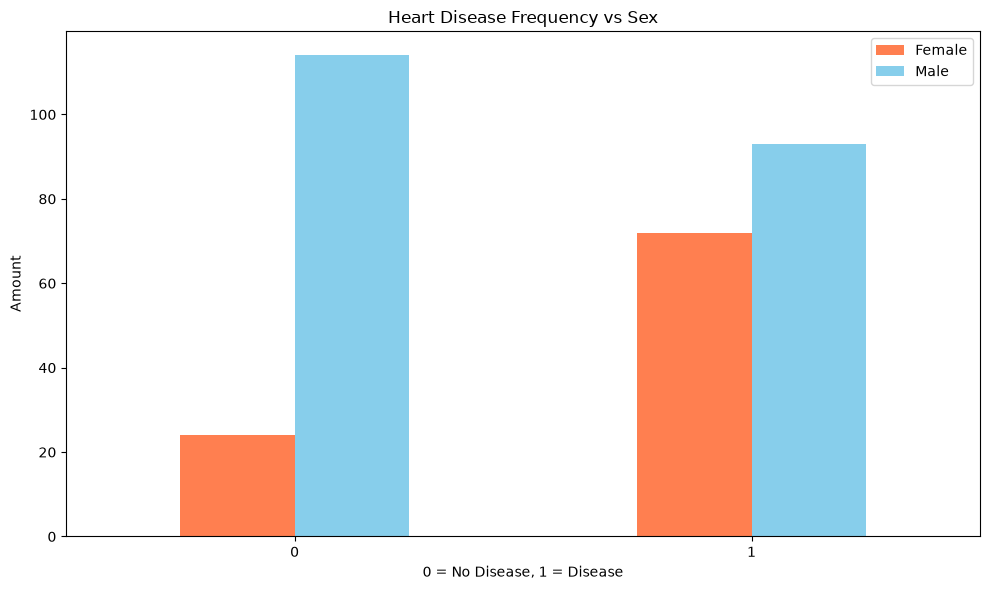

In [12]:
# Visualize the relationship between heart disease and sex
pd.crosstab(df.target, df.sex).plot(kind="bar", figsize=(10,6), color=["coral", "skyblue"])

plt.title("Heart Disease Frequency vs Sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0); 
plt.tight_layout()
plt.savefig("plots/02_EDA_heart_disease_vs_sex.png", dpi=300, bbox_inches='tight')
plt.show()

#####
# ~75% for women and ~45% for male
# ~55% of the dataset have heart disease -> baseline accuracy of 55% if we predict all patients have heart disease

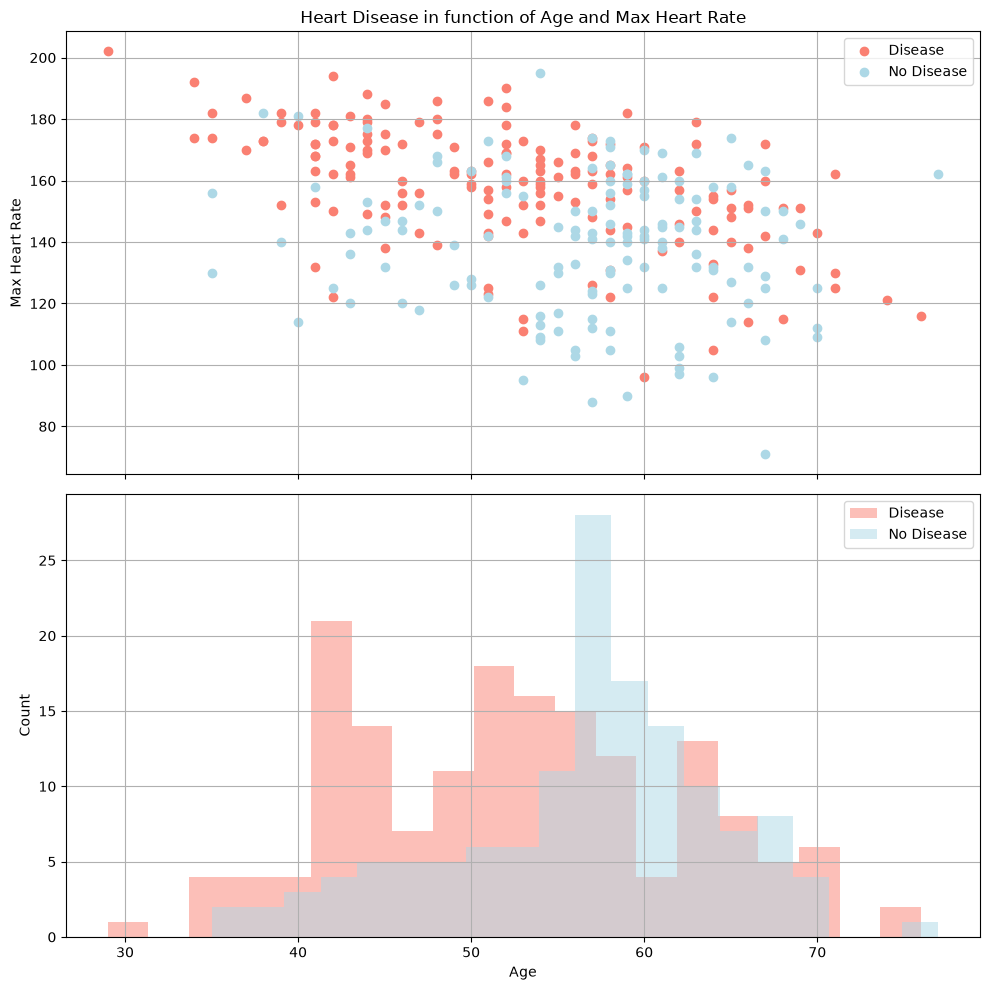

In [13]:
# Visualize the relationship between age and max heart rate, colored by target variable

fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

# Scatter plot of age vs max heart rate, colored by target variable
ax0.scatter(df.age[df.target==1], df.thalach[df.target==1], c="salmon", label="Disease")
ax0.scatter(df.age[df.target==0], df.thalach[df.target==0], c="lightblue", label="No Disease")
ax0.set(title="Heart Disease in function of Age and Max Heart Rate", ylabel="Max Heart Rate")
ax0.legend()
ax0.grid(True)

# Histogram of age distribution, colored by target variable
ax1.hist(df.age[df.target==1], bins=20, alpha=0.5, color="salmon", label="Disease")
ax1.hist(df.age[df.target==0], bins=20, alpha=0.5, color="lightblue", label="No Disease")
ax1.set(xlabel="Age", ylabel="Count")
ax1.legend()
ax1.grid(True)

plt.tight_layout()
plt.savefig("plots/03_EDA_heart_disease_vs_age_and_max_heart_rate.png", dpi=300, bbox_inches='tight')
plt.show()



# Younger -> higher max heart rate, older -> lower max heart rate
# Seems more heart disease in the younger population
# Normal distribution of age, slightly skewed to the right

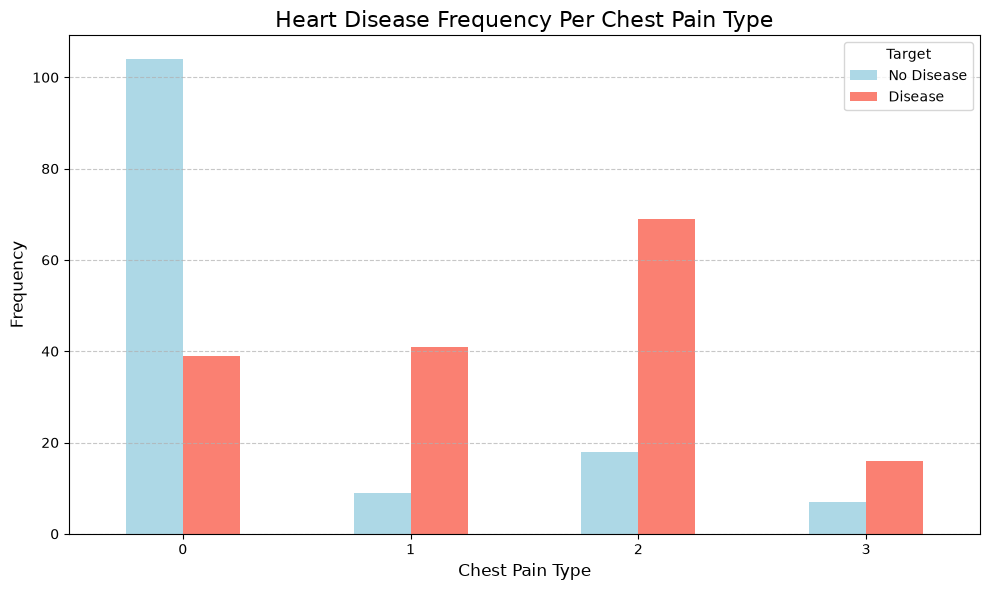

In [14]:
# Visualize the relationship between chest pain type and target variable

# Create a cross-tabulation of Chest Pain Type and Target
crosstab_result = pd.crosstab(df.cp, df.target)

# Plot the crosstab with a bar chart
ax = crosstab_result.plot(kind="bar", figsize=(10, 6), color=["lightblue", "salmon"])

# Add labels, title, and formatting for better readability
plt.title("Heart Disease Frequency Per Chest Pain Type", fontsize=16)
plt.xlabel("Chest Pain Type", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(["No Disease", "Disease"], title="Target")
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add subtle gridlines
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.savefig("plots/04_EDA_heart_disease_vs_chest_pain_type.png", dpi=300, bbox_inches='tight')
plt.show()

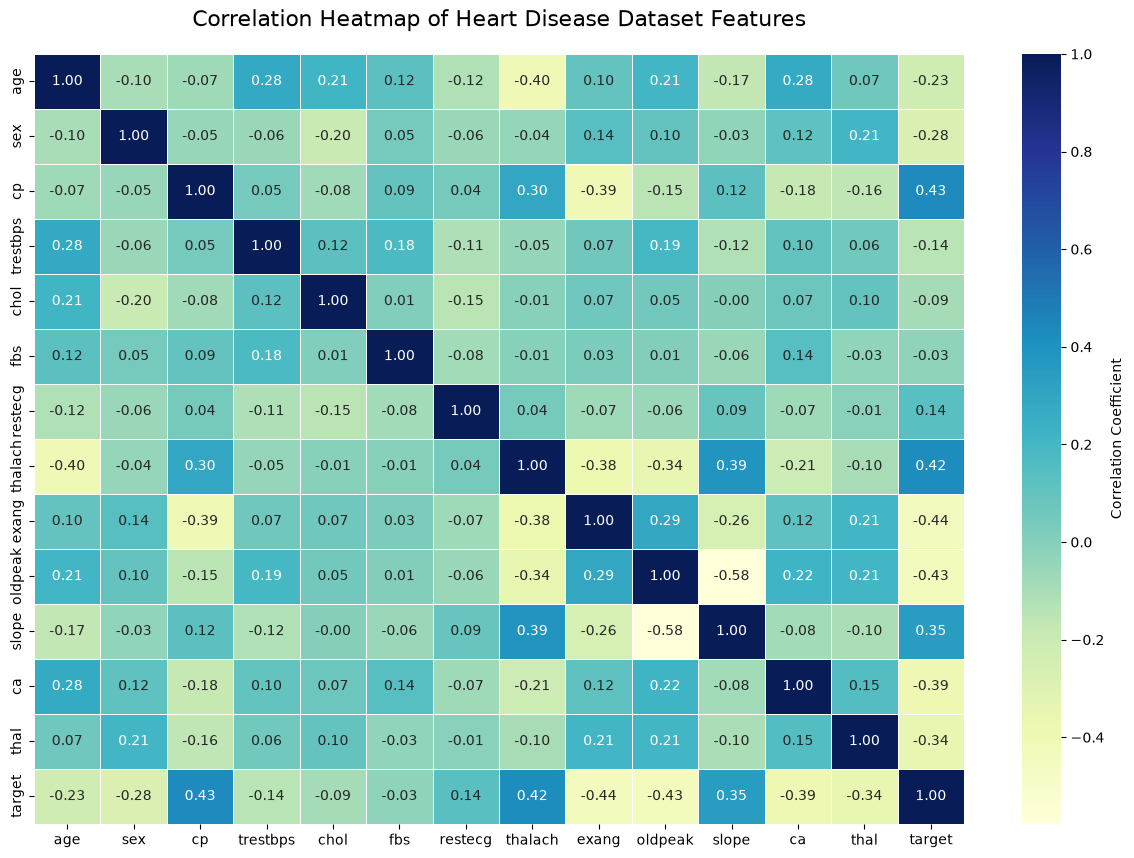

In [15]:
# Correlation between independent variables
# Calculate the correlation matrix
corr_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(15, 10))

# Create the heatmap with improved formatting
sns.heatmap(corr_matrix, 
            annot=True,          # Show the correlation coefficients
            linewidths=0.5,      # Add lines between cells
            fmt=".2f",           # Format to 2 decimal places
            cmap="YlGnBu",       # Use a professional color map
            cbar_kws={'label': 'Correlation Coefficient'}) # Add label to the color bar
plt.title("Correlation Heatmap of Heart Disease Dataset Features", fontsize=16, pad=20)
plt.savefig("plots/05_EDA_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()